In [136]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [150]:
length = 50
height = 50
board = np.zeros((length,height))
rng = np.random.default_rng()

In [139]:
def mvn(x, y, xmean=0, ymean=0, xvar=1, yvar=1):
    return np.e ** (-(((x-xmean)**2) / (2 * xvar) + ((y-ymean)**2)/(2 * yvar)))

# i reinvented the wheel! i could have simply used
# stats.multivariate_normal([1,1], np.array([[1,0],[0,1]]))
# and then 
# m.pdf([x,y])
# results check out though
def mvn_matrix(x, y, xmean, ymean, cov=np.array([[1,0],[0,1]])): #xy is a vector, default covariance is variance 1 for both and no covariance (independent x and y)
    xy = np.array([[x],[y]])
    mu = np.array([[xmean],[ymean]])
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    denom = np.sqrt(((2 * np.pi)**2) * det)
    num = np.e ** (-1/2 * (xy - mu).T @ inv @ (xy - mu))
    #return num             #2x1     -> 1x2      ->2x2 = 1x2 * 2x1 = 1x1
    return (num/denom)[0][0]
    

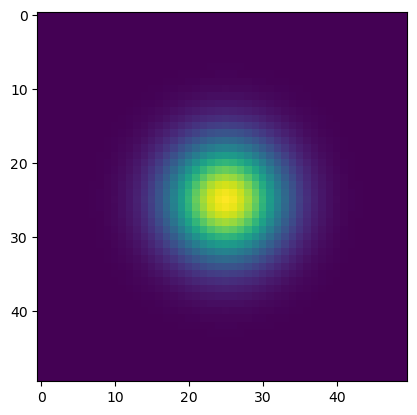

In [148]:
board = np.zeros((length,height))
for (x,y), v in np.ndenumerate(board):
    board[x,y] = mvn_matrix(x,y,25,25, np.array([[30,0],[0,30]]))
plt.figure()
plt.imshow(board)
plt.show()

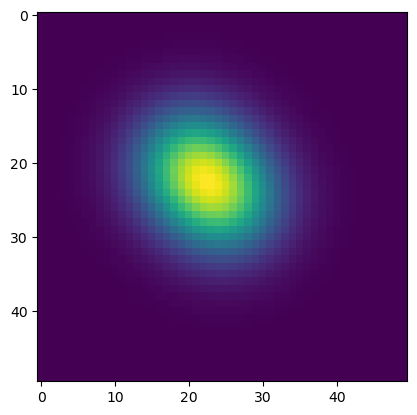

In [149]:
board = np.zeros((length,height))
for (x,y), v in np.ndenumerate(board):
    board[x,y] = mvn_matrix(x,y,25,25, np.array([[30,0],[0,30]]))
    board[x,y] += mvn_matrix(x,y,20,20, np.array([[30,0],[0,30]]))
plt.figure()
plt.imshow(board)
plt.show()